In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
# charger les donnes

df = pd.read_csv('../data/job_salary_prediction_dataset.csv')
print(f"Original dataset shape: {df.shape}")

df.head()

Original dataset shape: (250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [77]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

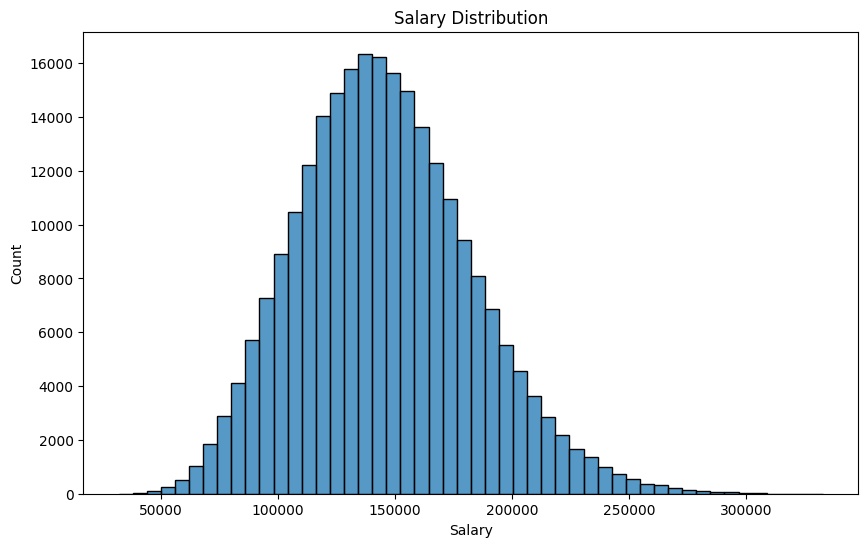

In [78]:
 plt.figure(figsize=(10,6))

sns.histplot(df["salary"], bins=50)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

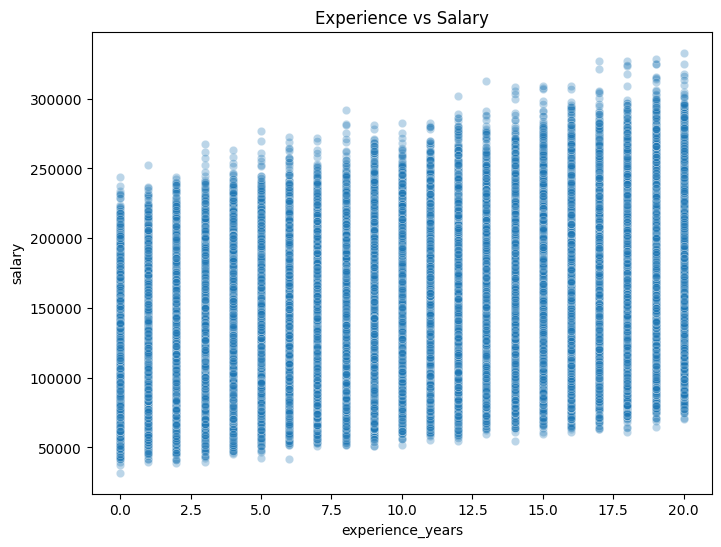

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="experience_years",
    y="salary",
    data=df,
    alpha=0.3
)

plt.title("Experience vs Salary")

plt.show()

In [80]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

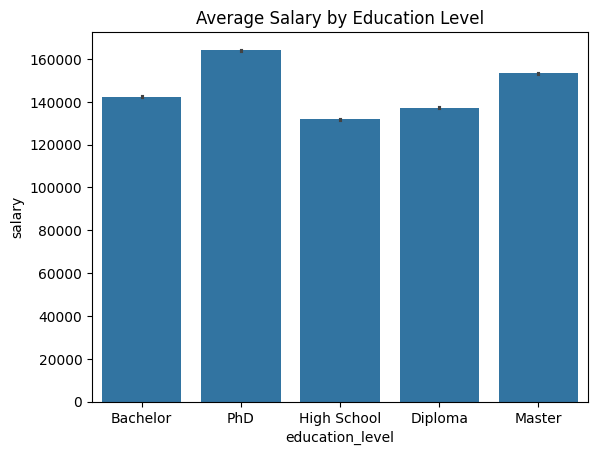

In [81]:
df.groupby("education_level")["salary"].mean().sort_values()
sns.barplot(
    x="education_level",
    y="salary",
    data=df
)

plt.title("Average Salary by Education Level")

plt.show()

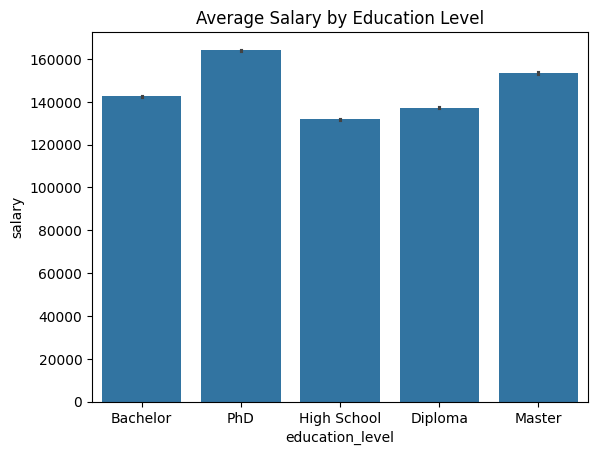

In [82]:
df.groupby("education_level")["salary"].mean().sort_values()
sns.barplot(
    x="education_level",
    y="salary",
    data=df
)

plt.title("Average Salary by Education Level")

plt.show()

<Axes: ylabel='salary'>

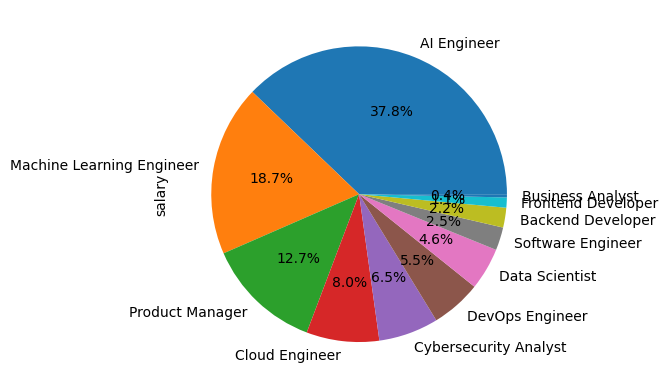

In [83]:
df1 = df[df['salary'] >= 250000].groupby('job_title').count()['salary'].sort_values(ascending = False)
df1.plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='year of experience'>

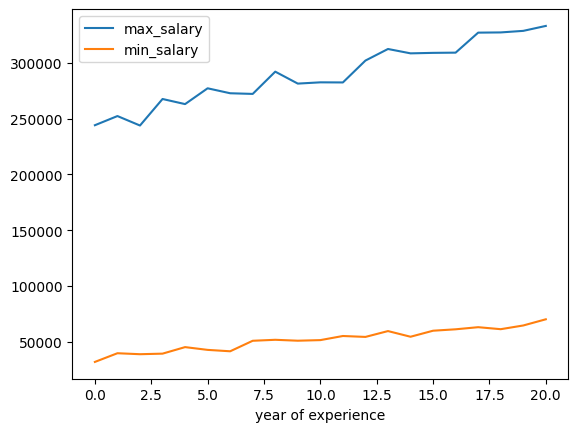

In [84]:
df3 = df.groupby('experience_years')['salary'].max()
df4 = df.groupby('experience_years')['salary'].min()
min_max_df = pd.merge(df3,df4,how = 'outer',on = df3.index)

min_max_df = min_max_df.rename(columns = {
    'key_0' : 'year of experience',
    'salary_x':'max_salary',
    'salary_y' : 'min_salary'
})
min_max_df.plot(x = 'year of experience', y = ['max_salary','min_salary'])

<Axes: xlabel='experience_years'>

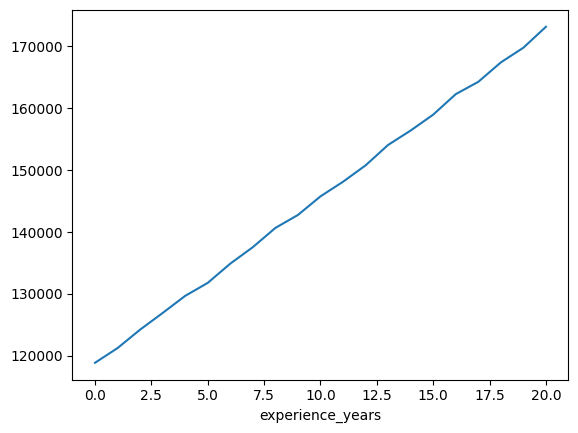

In [85]:
df.groupby('experience_years')['salary'].mean().plot()

In [86]:
columns = ['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
for i in columns:
    print(i)
    print(df[df['education_level']== i]['job_title'].value_counts())
    print()

Bachelor
job_title
Software Engineer            4222
Product Manager              4214
AI Engineer                  4212
Data Analyst                 4206
Cloud Engineer               4198
Cybersecurity Analyst        4182
Backend Developer            4179
Machine Learning Engineer    4172
Data Scientist               4145
Frontend Developer           4103
Business Analyst             4079
DevOps Engineer              4038
Name: count, dtype: int64

PhD
job_title
Product Manager              4259
DevOps Engineer              4234
Frontend Developer           4199
Data Scientist               4178
Cybersecurity Analyst        4154
AI Engineer                  4152
Software Engineer            4148
Data Analyst                 4141
Business Analyst             4139
Machine Learning Engineer    4134
Backend Developer            4067
Cloud Engineer               4052
Name: count, dtype: int64

High School
job_title
Backend Developer            4346
Cloud Engineer               4248
AI Engi

<Axes: xlabel='education_level'>

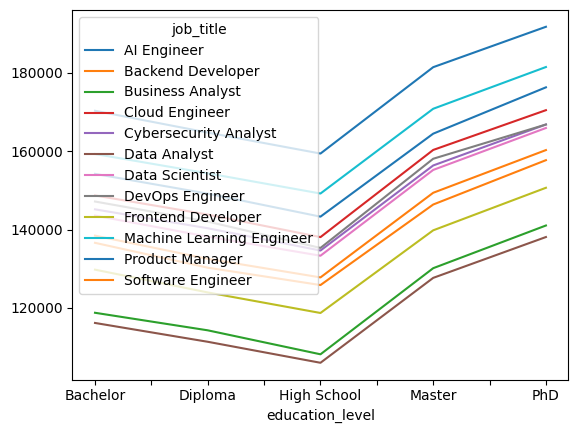

In [87]:
pd.pivot_table(df,index = 'education_level', columns= 'job_title', values = 'salary',aggfunc='mean').plot()

In [ ]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])